#Tutorial 3: Unsupervised Machine Learning — PCA and K-Means Clustering for Bearing Fault Detection

#Overview

In this tutorial, you will learn how to apply two foundational unsupervised machine learning techniques; Principal Component Analysis (PCA) and K-Means Clustering, to real-world bearing vibration data. The dataset contains time-domain vibration signals recorded from a rotating machine under four conditions:


##Background: Why Bearing Faults Matter

Rolling-element bearings are among the most common mechanical components in industry; motors, turbines, pumps, and conveyor systems all rely on them. When a bearing develops a defect on its inner race, outer race, or rolling element, the defect creates **periodic impacts** as the bearing rotates. These impacts appear as characteristic frequency patterns in vibration signals.

By learning to **detect and classify** these patterns automatically, we can:
- Schedule **preventive maintenance** before a catastrophic failure
- Reduce **downtime and repair costs**
- Enable **continuous, real-time monitoring** of rotating machines

We will work with **four bearing conditions**:

| Condition | Description |
|-----------|-------------|
| **Normal** | Healthy bearing, no defects |
| **Inner Race Fault** | Defect on the inner ring surface |
| **Roller Fault** | Defect on one of the rolling elements |
| **Outer Race Fault** | Defect on the stationary outer ring |

---
**By the end of this tutorial, you will be able to:**

- Convert raw vibration signals into frequency-domain feature representations (log-Mel spectrograms)
- Apply and interpret PCA for dimensionality reduction
- Use PCA features as inputs to a downstream classifier
- Run K-Means clustering and evaluate cluster quality without labels
---

#Background: Why Unsupervised Learning?
In many industrial fault detection scenarios, obtaining labelled data is expensive or impractical. A machine may run for months before a fault appears, and human inspection is required to annotate each recorded signal. Unsupervised learning allows us to discover structure in data without relying on labels.

Two key questions we can answer unsupervised:

1. Can we compress the data (thousands of features per sample) into a small number of meaningful dimensions? → PCA answers this.
2. Do the compressed representations naturally group by fault type? → K-Means answers this.

# 1) Load audio & build features (log-Mel spectrogram)
# What is a Log-Mel Spectrogram?
Raw vibration signals are one-dimensional time series, a sequence of amplitude values sampled at a fixed rate (here, fs = 10,000 Hz, meaning 10,000 samples per second). While you could feed these raw samples directly into a model, they are noisy and very high-dimensional.
A log-Mel spectrogram is a compact, perceptually motivated representation of a signal in the frequency domain. Here is how it is constructed:

1. Windowing: Slice the signal into short overlapping windows (e.g., 0.5 s × 10,000 Hz = 5,000 samples per window).
2. Short-Time Fourier Transform (STFT): Convert each window from time domain to frequency domain, showing which frequencies are present and how strongly.
3. Mel filter bank: Group frequencies into 64 perceptual "Mel" bins. The Mel scale compresses high frequencies and expands low frequencies, better reflecting how vibration energy distributes in fault signatures.
4. Log transform: Take the logarithm of the filter bank outputs. This converts multiplicative noise patterns into additive ones and stabilises variance across frequency bins.
5. Flatten: Reshape the 2D spectrogram matrix (64 Mel bins × time frames) into a single long feature vector per window.

The result is a fixed-length, information-dense feature vector for each windowed segment of the vibration signal.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display as lplt
from scipy.io import loadmat

# Load the .mat file
file_path = '/content/drive/My Drive/ME483/dataset.mat'
dataset = loadmat(file_path)

# Inspect available keys
print("Keys in the dataset:")
for key in dataset:
    if not key.startswith('__'):
        print(f"  - {key} | Type: {type(dataset[key])} | Shape: {np.shape(dataset[key])}")

Mounted at /content/drive
Keys in the dataset:
  - normal | Type: <class 'numpy.ndarray'> | Shape: (1, 120000)
  - inner | Type: <class 'numpy.ndarray'> | Shape: (1, 120000)
  - roller | Type: <class 'numpy.ndarray'> | Shape: (1, 120000)
  - outer | Type: <class 'numpy.ndarray'> | Shape: (1, 120000)


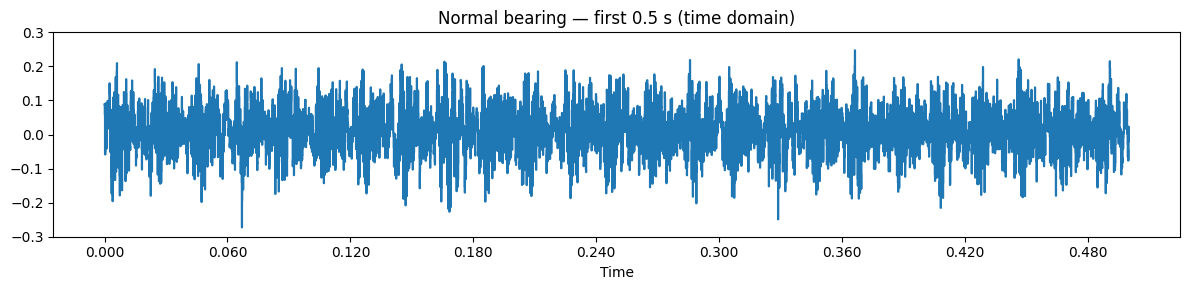

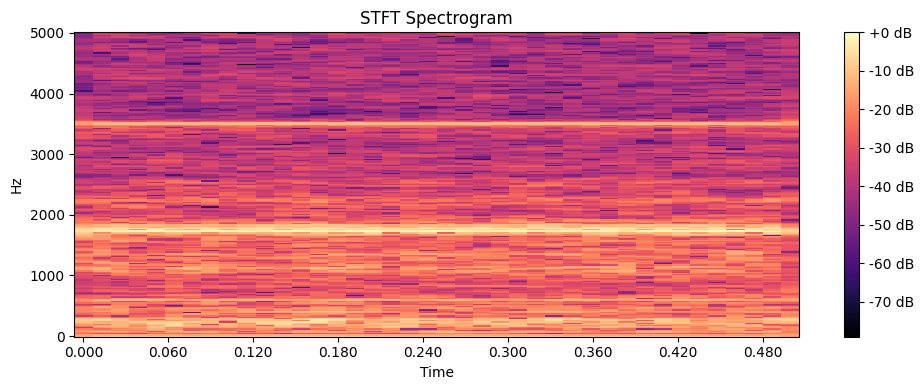

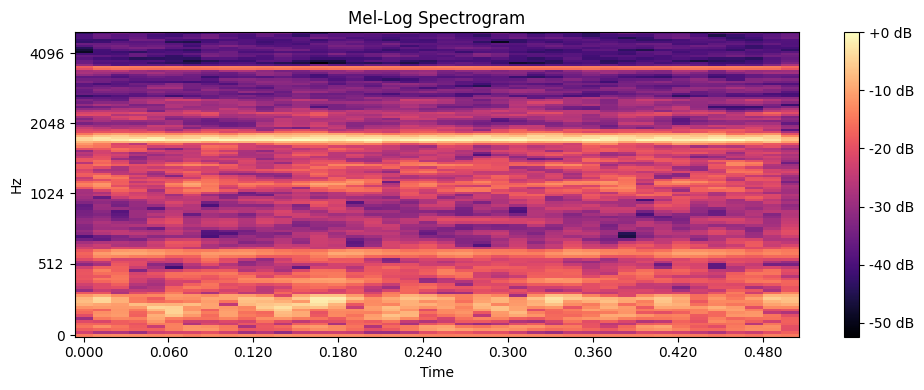

In [3]:
# Parameters
duration_sec = 0.5    # Window length in seconds
size_max     = 120000 # Maximum samples to use per condition
fs           = 10000  # Sampling frequency (Hz)

# Extract raw 1D signals, truncated to size_max
sig_normal = dataset["normal"].reshape(-1)[:size_max]
sig_inner  = dataset["inner"].reshape(-1)[:size_max]
sig_roller = dataset["roller"].reshape(-1)[:size_max]
sig_outer  = dataset["outer"].reshape(-1)[:size_max]

# Use first 0.5 s for visualization
signal = sig_normal[:int(duration_sec * fs)]

# Time-domain waveform

plt.figure(figsize=(12,3))
lplt.waveshow(signal, sr=fs)
plt.title("Normal bearing — first 0.5 s (time domain)")
plt.tight_layout()
plt.show()

n_fft = 512
hop_length = 128

D = librosa.stft(signal,
                 n_fft=n_fft,
                 hop_length=hop_length)

D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    D_db,
    sr=fs,
    hop_length=hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar(format='%+2.0f dB')
plt.title('STFT Spectrogram')
plt.tight_layout()
plt.show()

mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=fs,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=128
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=fs,
    hop_length=hop_length,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Log Spectrogram')
plt.tight_layout()
plt.show()

In [5]:
import IPython
duration_samples = 0.2    # Length of each analysis segment (seconds).
                           # 0.2 s = 200 ms — short enough to capture a few impacts,
                           # long enough to resolve frequency patterns.

size_max = 120_000         # Total samples we will use per class.

frequence = 10_000         # Sampling rate in Hz (10 kHz)


# Extract the four bearing signals
# dataset[key] is a 2-D NumPy array from MATLAB; .reshape(-1) flattens it to 1-D.
# [:size_max] trims to our chosen length so all four arrays have equal size.
df_normal = dataset["normal"].reshape(-1)[:size_max]
df_inner  = dataset["inner" ].reshape(-1)[:size_max]
df_roller = dataset["roller"].reshape(-1)[:size_max]
df_outer  = dataset["outer" ].reshape(-1)[:size_max]

# Group them into a list for easy iteration later
data = [df_normal, df_inner, df_roller, df_outer]
class_names = ["Normal", "Inner Fault", "Roller Fault", "Outer Fault"]

print(f"Each signal: {size_max:,} samples → {size_max/frequence:.1f} seconds of data")
IPython.display.Audio(df_normal[:20_000], rate=frequence)


Each signal: 120,000 samples → 12.0 seconds of data


In [ ]:
# Window and hop sizes
win      = int(duration_sec * fs)   # samples per window (e.g., 5000 for 0.5 s)
hop      = win // 2                  # 50% overlap between consecutive windows

n_mels   = 64    # number of Mel frequency bins
n_fft    = 1024  # FFT size (frequency resolution)
hop_spec = 256   # STFT hop size (within each window)

def windows(x, win, hop):
    """Generator that yields overlapping windows from signal x."""
    for start in range(0, max(0, len(x) - win + 1), hop):
        yield x[start:start + win]

def window_to_logmel(xw, sr=fs):
    """Convert one window of samples to a flattened log-Mel feature vector."""
    xw = np.asarray(xw, dtype=float)
    if xw.size == 0:
        return None
    xw = xw - np.mean(xw)   # Remove DC offset (zero-mean the window)
    S = librosa.feature.melspectrogram(
        y=xw, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_spec, power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)  # Convert power to dB (log scale)
    return S_db.flatten()                        # Shape: (n_mels * T_frames,)

# Build feature matrix X and label vector y
X_list, y_list = [], []
label_map = {
    "normal": sig_normal,
    "inner":  sig_inner,
    "roller": sig_roller,
    "outer":  sig_outer,
}

for label, sig in label_map.items():
    for xw in windows(sig, win, hop):
        feat = window_to_logmel(xw, sr=fs)
        if feat is not None:
            X_list.append(feat)
            y_list.append(label)

X = np.vstack(X_list)   # Shape: [n_windows, n_mels * T_per_window]
y = np.array(y_list)

print("Feature matrix shape:", X.shape)
print("Class distribution:", pd.Series(y).value_counts().to_dict())

Feature matrix shape: (188, 1280)
Class distribution: {'normal': 47, 'inner': 47, 'roller': 47, 'outer': 47}


Key concepts:

- X is your feature matrix: each row is one window (one data sample), each column is one feature dimension.
- y holds the class label for each window, available for evaluation, but not used in the unsupervised steps.
- The number of columns in X will be large (typically several hundred to a few thousand). PCA will reduce this drastically.
- The hop = win // 2 means consecutive windows share 50% of their samples, which increases dataset size and smooths out edge effects.

# Step 2: Standardization and PCA

##Why Standardize?

PCA finds directions of maximum variance. If one feature has a naturally large scale (e.g., values in the hundreds) and another is small (values near zero), PCA will be dominated by the large-scale feature regardless of its actual informativeness. StandardScaler corrects this by transforming every feature to have:

- Mean = 0 (with_mean=True), centres the data at the origin
- Standard deviation = 1 (with_std=True),  puts all features on equal footing

After scaling, PCA will find directions that genuinely capture the most meaningful variation in the data, not just the features with the largest raw magnitude.

## What Does PCA Do?
PCA finds a new coordinate system for your data defined by principal components (PCs):

- PC1 is the direction in feature space along which the data varies the most.
- PC2 is the direction of second-greatest variance, constrained to be perpendicular (orthogonal) to PC1.
- PC3, PC4, ... continue in decreasing order of variance explained, each orthogonal to all previous ones.

Mathematically, PCA solves for the eigenvectors of the data covariance matrix. The eigenvectors define the principal axes; the corresponding eigenvalues tell you how much variance each axis captures. Projecting data onto the first K principal components gives a compressed representation that retains the most important structure while discarding noise.


For bearing fault detection, the hope is that the dominant axes of variation correspond to fault type, meaning faults that produce different vibration patterns will naturally separate along the first few PCs.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Standardize the features
scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X)
# Xz has the same shape as X, but every column now has mean=0, std=1

# Step 2: Fit PCA — compute the top 100 principal components
n_comp = min(100, X.shape[1])   # Cap at 100 for speed
pca = PCA(n_components=n_comp, random_state=42)
Z = pca.fit_transform(Xz)
# Z has shape [n_samples, n_comp]
# Each column of Z is the projection of all samples onto one principal component

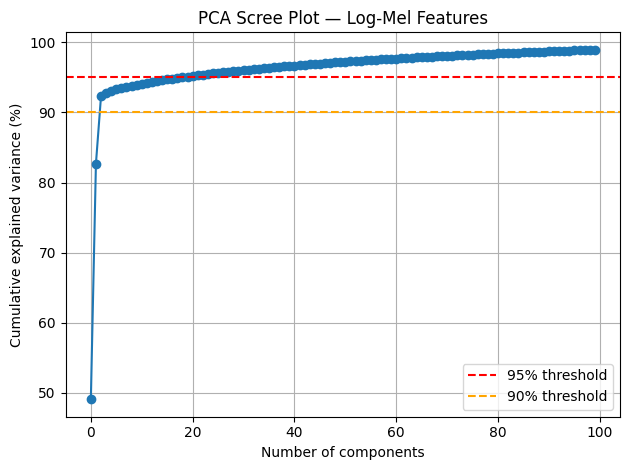

Components for 90% variance: K90 = 3
Components for 95% variance: K95 = 19


In [ ]:
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure()
plt.plot(cumvar, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance (%)')
plt.title('PCA Scree Plot — Log-Mel Features')
plt.axhline(95, color='r', linestyle='--', label='95% threshold')
plt.axhline(90, color='orange', linestyle='--', label='90% threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Find how many components capture 95% of variance
K95 = int(np.searchsorted(cumvar, 95.0) + 1)
K90 = int(np.searchsorted(cumvar, 90.0) + 1)
print(f"Components for 90% variance: K90 = {K90}")
print(f"Components for 95% variance: K95 = {K95}")

**How to read the scree plot:**

- A steep initial rise followed by a flattening elbow indicates that a small number of PCs capture most of the information. This means the data has low effective dimensionality, good news for compression.
- The elbow point is often chosen as the natural number of components to keep.
- K95 is the minimum number of components required to explain 95% of total variance. This is a common practical threshold, it discards the bottom 5%, which is mostly noise.
- For bearing fault data with log-Mel features, you may find that only 10–30 components are needed to reach 95%, even though the raw feature space has hundreds of dimensions.

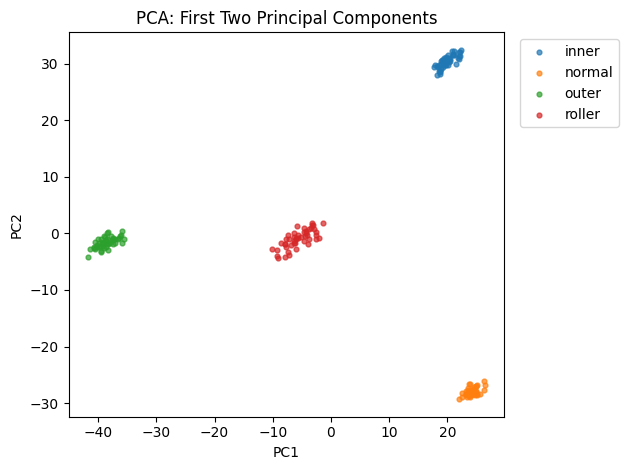

In [ ]:
plt.figure()
classes = np.unique(y)
for lbl in classes:
    mask = (y == lbl)
    plt.scatter(Z[mask, 0], Z[mask, 1], s=12, alpha=0.7, label=str(lbl))

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Principal Components')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:**

- If the four fault classes form distinct, well-separated clusters in the PC1–PC2 plane, it means the dominant axes of variation correspond to the fault type.
- If clusters overlap significantly, the fault discrimination requires more than 2 components, or a different feature representation.
- Even imperfect 2D separation can indicate that the full K95-dimensional PCA space is well-separable,  this is why you always check the classifier (Step 5) in addition to the scatter plot.
- Look for the normal class, it often sits apart from the three fault classes, since it has a distinctly different spectral profile.

#Step 3: PCA Reconstruction — How Many Components Are Enough?
One of the most intuitive ways to understand PCA compression is to reconstruct a sample from a limited number of principal components and compare visually to the original spectrogram.
#The Reconstruction Process
Reconstruction works in three steps:

1. Project: Take a standardized sample xz and compute its PCA scores: z = pca.transform(xz). This gives coordinates in the PC space.
2. Truncate: Keep only the first K scores and zero out the rest: zK[:, K:] = 0.
3. Invert: Apply pca.inverse_transform(zK) to map back to feature space, then scaler.inverse_transform() to restore original units.

If K captures enough variance, the reconstruction looks nearly identical to the original. If K is too small, fine spectral structure is lost and the reconstruction appears blurred or distorted.

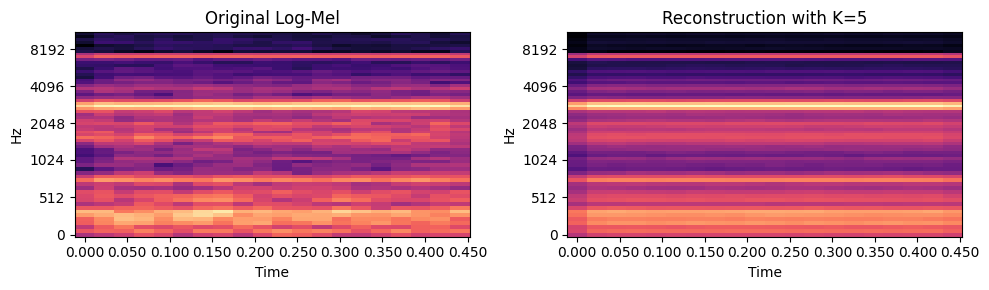

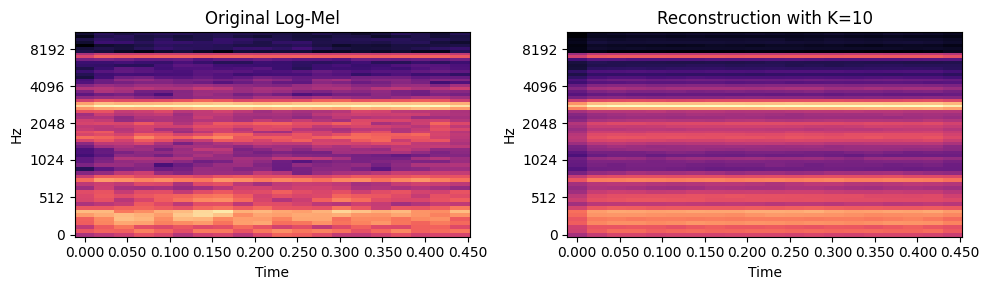

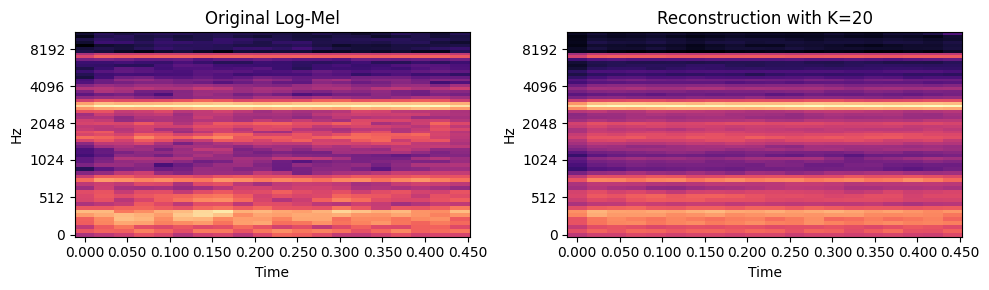

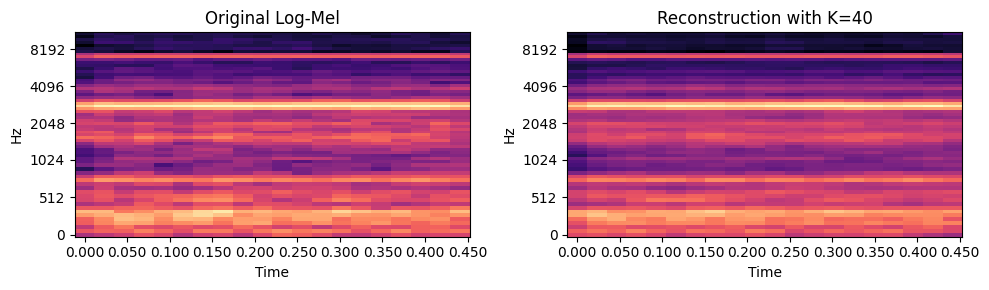

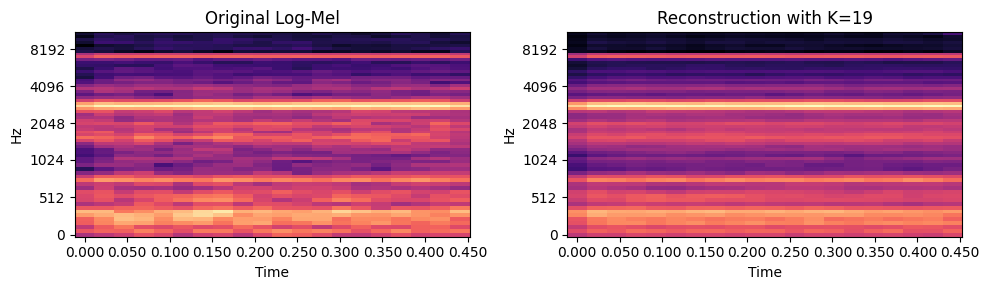

In [ ]:
import librosa.display as lplt

idx = 0                      # Index of the sample to reconstruct (try different ones)
Ks  = [5, 10, 20, 40, K95]  # Try these component counts

n_mels = 64
T = X.shape[1] // n_mels    # Number of time frames per window

xz = Xz[idx:idx+1]          # Standardized feature row, shape (1, n_features)
z  = pca.transform(xz)      # Project into PCA space, shape (1, n_comp)

for K in Ks:
    K_eff = min(K, z.shape[1])

    # Zero-pad: keep only first K_eff components, set rest to 0
    zK = np.zeros_like(z)
    zK[:, :K_eff] = z[:, :K_eff]

    # Invert PCA projection, then invert standardization
    xz_rec = pca.inverse_transform(zK)
    x_rec  = scaler.inverse_transform(xz_rec)

    # Reshape back to 2D spectrogram for visualization
    mel_orig = X[idx].reshape(n_mels, T)
    mel_rec  = x_rec.reshape(n_mels, T)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    lplt.specshow(mel_orig, ax=axes[0], x_axis='time', y_axis='mel')
    axes[0].set_title("Original Log-Mel")

    lplt.specshow(mel_rec, ax=axes[1], x_axis='time', y_axis='mel')
    axes[1].set_title(f"Reconstruction with K={K_eff}")

    plt.tight_layout()
    plt.show()

What to observe as K increases:

- K=5: Very coarse reconstruction. Low-frequency trends are preserved but high-frequency spectral detail is lost.
- K=10–20: Major spectral bands start to appear. The fault's characteristic frequency pattern becomes recognisable.
- K=40: Near-original quality for most samples. Fine detail is mostly preserved.
- K=K95: By definition, 95% of the variance is restored. The reconstruction should be visually almost indistinguishable.



#Step 4: Supervised Sanity Check — Logistic Regression on PCA Features
Before running unsupervised clustering, it is useful to confirm that the PCA-compressed features are actually informative. A simple logistic regression classifier provides this sanity check.

**Why Do This Before Clustering?**

If even a basic linear classifier cannot separate the classes using PCA features, then K-Means clustering has little hope. This step answers two questions:

1. Does the log-Mel + PCA pipeline capture fault-relevant information?
2. Is K95 a reasonable compression level, or are we losing too much?

If classification accuracy is high (> 85%), you can proceed to clustering with confidence. If it is low, revisit the feature extraction parameters (window size, n_mels, n_fft) before expecting K-Means to work

              precision    recall  f1-score   support

       inner       1.00      1.00      1.00        12
      normal       1.00      1.00      1.00        11
       outer       1.00      1.00      1.00        12
      roller       1.00      1.00      1.00        12

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47



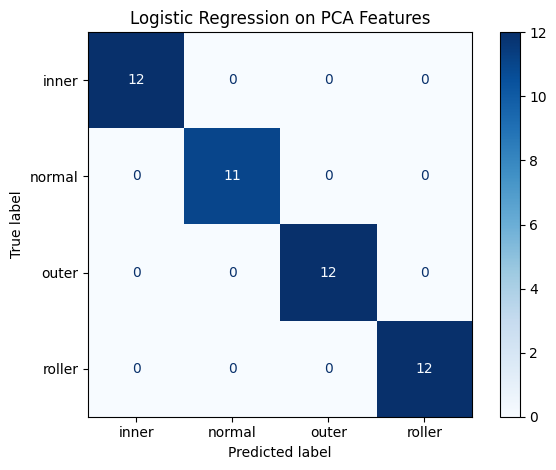

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Use only the first K95 principal components as features
ZK = Z[:, :K95]

# Train/test split — stratified to ensure equal class representation
Xtr, Xte, ytr, yte = train_test_split(
    ZK, y, test_size=0.25, random_state=42, stratify=y
)

# Logistic regression (linear boundary in PCA space)
clf = LogisticRegression(max_iter=300)
clf.fit(Xtr, ytr)
yhat = clf.predict(Xte)

# Per-class performance report
print(classification_report(yte, yhat))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(yte, yhat, cmap='Blues', values_format='d')
plt.title("Logistic Regression on PCA Features")
plt.tight_layout()
plt.show()

#Step 5: K-Means Clustering on PCA Space
Now we turn fully unsupervised. K-Means treats the labels as unknown and asks: can the algorithm discover the four fault conditions on its own?

**How K-Means Works**

K-Means is an iterative algorithm that partitions N data points into K clusters by minimising within-cluster sum of squares (inertia):

1. Initialise: Place K cluster centroids in feature space. With n_init=10 and K-Means++ initialisation, the algorithm runs 10 independent restarts and keeps the best result, avoiding poor local minima.
2. Assign: Label each data point with the index of its nearest centroid (Euclidean distance).
3. Update: Recompute each centroid as the mean of all points currently assigned to it.
4. Repeat steps 2–3 until assignments stop changing (convergence) or a maximum iteration count is reached.

**Important properties:**

- K-Means requires you to specify K in advance. Here we use K = 4 (matching the four known conditions). In the Elbow Method section below, you will see how to estimate K when it is unknown.
- The algorithm minimises inertia, total squared distance from each point to its centroid. Lower inertia means tighter, more compact clusters.
- K-Means assumes spherical, roughly equal-sized clusters. It will struggle if fault classes are elongated, curved, or very different in size.

**Evaluating Clusters: Adjusted Rand Index (ARI)**
Since we have ground-truth labels (even though K-Means doesn't use them), we can evaluate cluster quality using the Adjusted Rand Index (ARI):

- ARI = 1.0: Perfect agreement between cluster assignments and true labels.
- ARI = 0.0: No better than random assignment.
- ARI < 0: Worse than random (rare in practice).

The ARI is label-invariant: Cluster 0 matching class "inner" is just as good as Cluster 0 matching class "outer", what matters is that each cluster is dominated by samples from one class, regardless of which cluster number is assigned to which class

Adjusted Rand Index (2-D PCA): 1.000


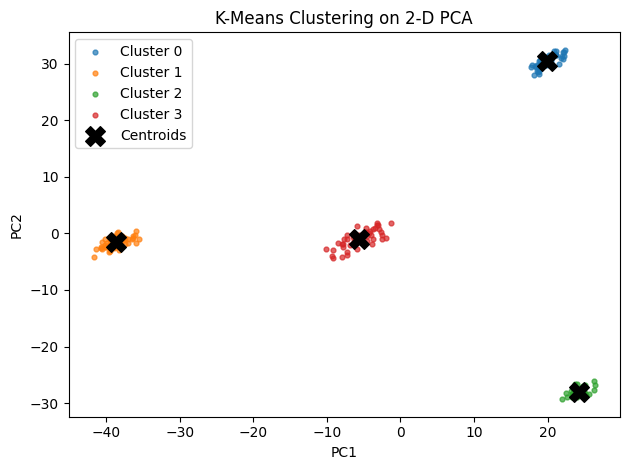

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Use only the first 2 PCs for easy 2D visualization
Z2 = Z[:, :2]

kmeans = KMeans(n_clusters=len(np.unique(y)), n_init=10, random_state=42)
labels = kmeans.fit_predict(Z2)

# Evaluate against ground truth
ari = adjusted_rand_score(y, labels)
print(f"Adjusted Rand Index (2-D PCA): {ari:.3f}")

# Plot: colour by discovered cluster
plt.figure()
for k in np.unique(labels):
    mask = (labels == k)
    plt.scatter(Z2[mask, 0], Z2[mask, 1], s=12, alpha=0.7, label=f"Cluster {k}")

# Show centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker='X', s=200, c='black', zorder=5, label='Centroids'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering on 2-D PCA')
plt.legend()
plt.tight_layout()
plt.show()

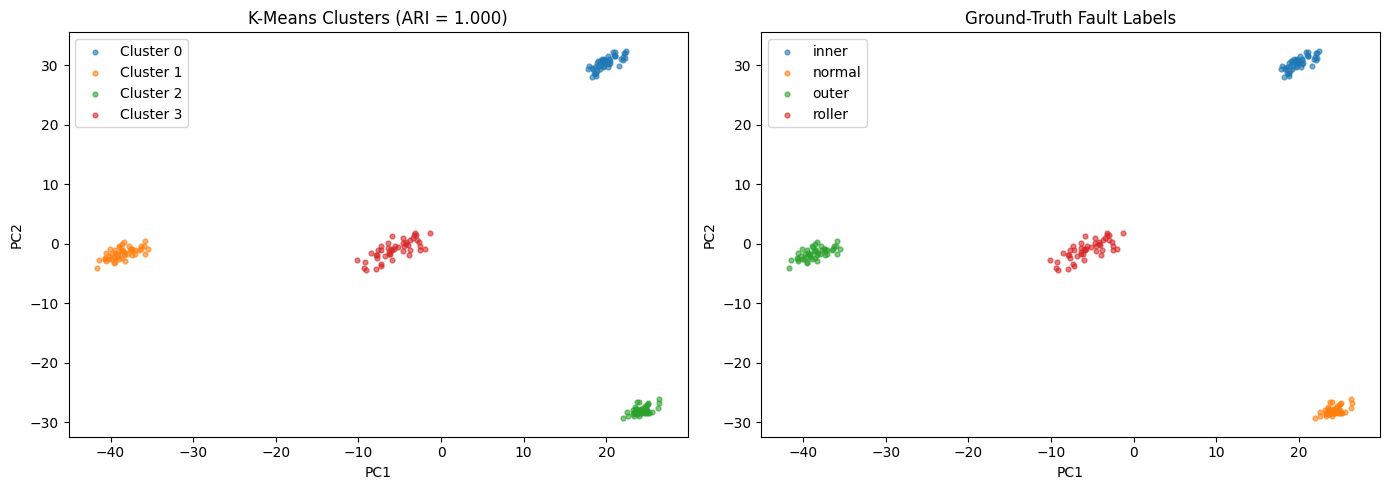

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means discovered clusters
for k in np.unique(labels):
    mask = (labels == k)
    axes[0].scatter(Z2[mask, 0], Z2[mask, 1], s=12, alpha=0.6, label=f"Cluster {k}")
axes[0].set_title(f"K-Means Clusters (ARI = {ari:.3f})")
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Right: True fault labels
for lbl in np.unique(y):
    mask = (y == lbl)
    axes[1].scatter(Z2[mask, 0], Z2[mask, 1], s=12, alpha=0.6, label=lbl)
axes[1].set_title("Ground-Truth Fault Labels")
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

**What to look for:**

- How closely do the K-Means cluster boundaries match the true class boundaries?
- Are any two fault types consistently merged into one cluster? This would suggest their spectral signatures are similar in 2D PCA space.
- Try repeating with Z[:, :K95] instead of Z[:, :2] — does the ARI improve? It often does substantially, since 2D discards most variance.

#Choosing the Number of Clusters: The Elbow Method
If you did not know there were 4 fault types, you could estimate K using the inertia elbow method:

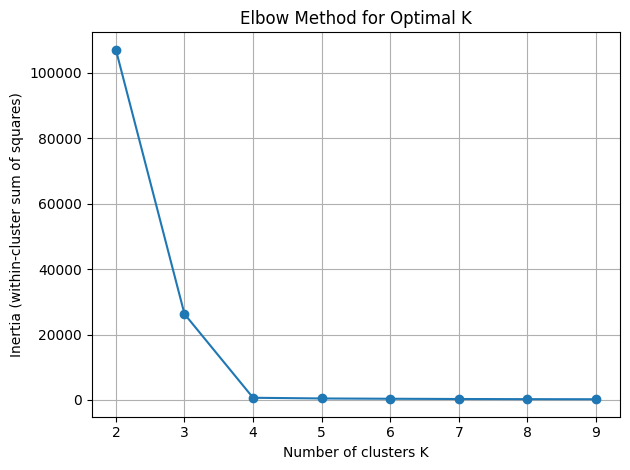

In [ ]:
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(Z2)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** Inertia always decreases as K increases, more clusters means a tighter fit. The "elbow" is the point where adding another cluster provides rapidly diminishing returns. For this dataset with four distinct fault types, you should see a clear elbow at K = 4.

# Excercise:
- Window length duration_sec = 0.1 → 0.2 → 0.5
Check: #windows produced, scree curve (K for 90/95%), reconstruction quality, PC1–PC2 separation.
- hop = win (no overlap) vs hop = win//2 (50%) vs hop = win//4 (75%)
Check: dataset size, stability of PCs, any change in downstream accuracy.
- Use StandardScaler(with_mean=True, with_std=True) vs with_std=False.
Check: how the scree and PCs change; does scaling help class separation?
- Use K90 / K95 / K99 for reconstruction and downstream steps.
Check: MSE of reconstructions, visual differences in spectrograms, classifier/clustering behavior.